Problem Statement:
Predicting house prices accurately is a critical real estate challenge.

Goal:
The goal is to build a regression model that predicts sale prices based
on property features such as quality, size, location, and construction.

Importing Libraries and loading the dataset:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv('train.csv')
print(df.shape)
df[['LotArea','BedroomAbvGr','Neighborhood','SalePrice']].head(10)

(1460, 81)


,LotArea,BedroomAbvGr,Neighborhood,SalePrice
0,8450,3,CollgCr,208500
1,9600,3,Veenker,181500
2,11250,3,CollgCr,223500
3,9550,3,Crawfor,140000
4,14260,4,NoRidge,250000
5,14115,1,Mitchel,143000
6,10084,3,Somerst,307000
7,10382,3,NWAmes,200000
8,6120,2,OldTown,129900
9,7420,2,BrkSide,118000


Data Preprocessing:

In [4]:
# Select key features for simplicity
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'YearBuilt',
'OverallQual', 'GarageCars', 'TotalBsmtSF']
target = 'SalePrice'
# Use only selected columns
df_model = df[features + [target]].copy()
# Fill missing values with median
df_model.fillna(df_model.median(), inplace=True)
print('Remaining missing values:', df_model.isnull().sum().sum())

Remaining missing values: 0


Exploratory Data Analysis:

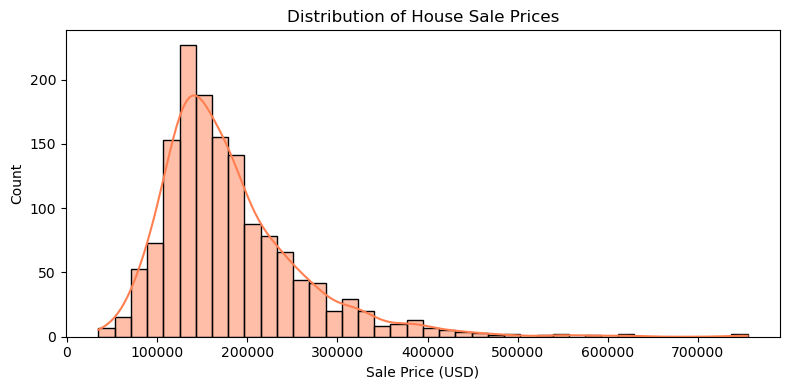

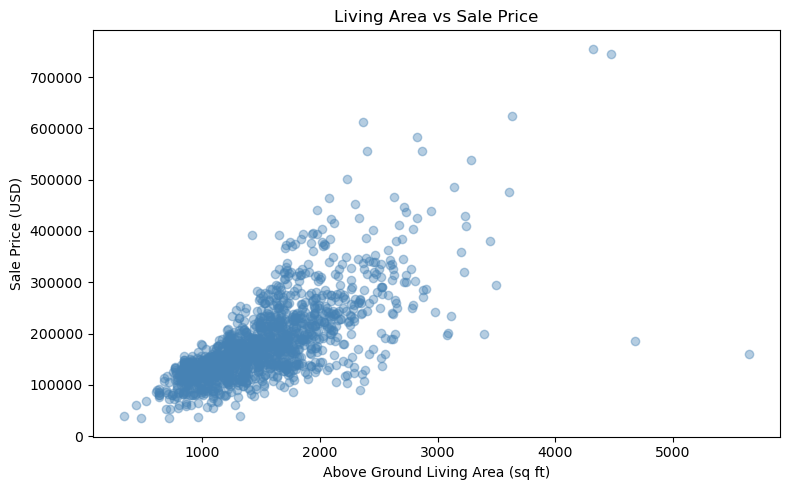

In [5]:
# Distribution of house prices
plt.figure(figsize=(8,4))
sns.histplot(df_model['SalePrice'], bins=40, kde=True, color='coral')
plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price (USD)')
plt.tight_layout(); plt.show()

# Living area vs price
plt.figure(figsize=(8,5))
plt.scatter(df_model['GrLivArea'], df_model['SalePrice'],
alpha=0.4, color='steelblue')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price (USD)')
plt.title('Living Area vs Sale Price')
plt.tight_layout(); plt.show()

Training the Model:

In [6]:
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# Gradient Boosting (more powerful than Linear Regression)
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Model trained!')

Model trained!


Evaluating with MAE and RMSE:

In [7]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: ${mae:,.0f}')
print(f'Root Mean Sq Error: ${rmse:,.0f}')
print(f'R2 Score: {r2:.4f}')

Mean Absolute Error: $19,139
Root Mean Sq Error: $28,810
R2 Score: 0.8918


Plotting Actual vs Predicted Prices:

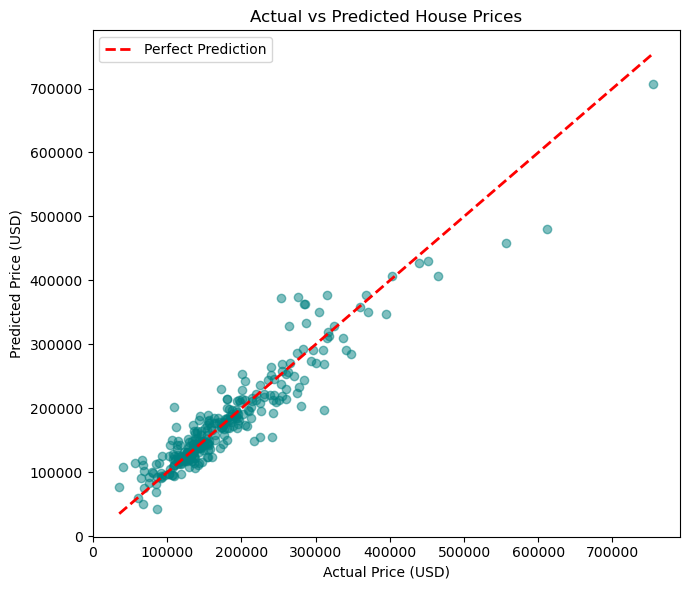

In [8]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()],
 [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted House Prices')
plt.legend(); plt.tight_layout(); plt.show()

Feature Importance:

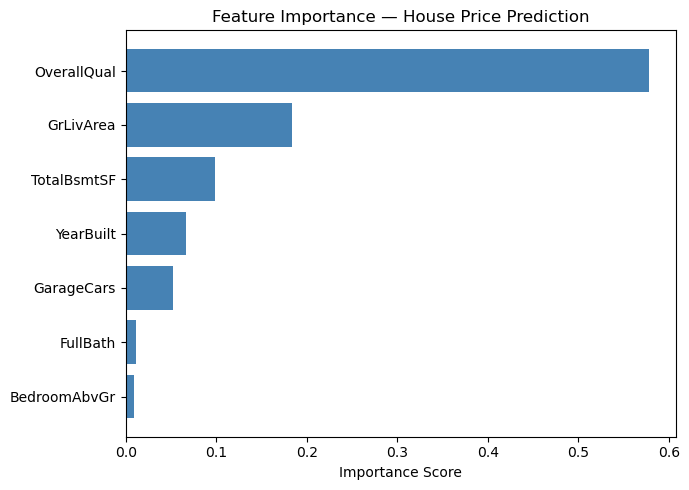

In [9]:
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)
plt.figure(figsize=(7,5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance — House Price Prediction')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

Explanation:

Task 6 — House Price Prediction

1.Dataset:
  Source: House Prices - Advanced Regression Techniques (Kaggle)
  Samples: 1460 houses, 81 features
  Target Column: SalePrice (ranges from $34,900 to $755,000)

2.Steps Performed:
 > Loaded dataset and explored key columns (LotArea, BedroomAbvGr, Neighborhood, SalePrice)
 > Checked missing values — none found in key features
 > Performed EDA — sale price distribution and living area vs price
 > Trained Gradient Boosting Regression model
 > Evaluated using MAE, RMSE, and R² Score
 > Plotted Actual vs Predicted prices
 >Identified most important features using feature importance

3.EDA Findings:
 > Sale price distribution is right-skewed  (most houses sell between $100,000–$200,000 with few luxury properties above $500,000)
 > Strong positive relationship between living area (GrLivArea) and sale price (larger houses consistently sell for more)
 >A few outliers exist with very large living areas but surprisingly low sale prices
  
4.Models used:
 Mean Absolute Error: $19,139 
 Root Mean Squared Error: $28,810 
 R² Score: 0.8918 

5.Results interpretation:
 >MAE $19,139: predictions are off by $19,139 on average. Acceptable given house prices range up to $755,000
 >RMSE $28,810: slightly higher than MAE indicating a few larger errors on unusual or luxury properties
 >R² 0.8918: model explains 89.18% of price variation.Strong and reliable result
  
6.Feature Importance Findings
 >OverallQual dominates with importance score ~0.57 — overall quality rating is by far the strongest predictor of house price
 >GrLivArea second at ~0.18 — larger living area means higher price
 >TotalBsmtSF third — basement size also significantly impacts price
 >YearBuilt and GarageCars follow — newer homes with larger garages sell for more
 >FullBath and BedroomAbvGr have minimal individual impact compared to quality and size
  
7.Key Takeaway
Overall quality rating and living area are the two most dominant factors in predicting house prices. The model performs strongly with R² of 0.89 and the Actual vs Predicted plot shows predictions closely follow the perfect prediction line for most houses.

8.Tools Used
 Python, pandas, NumPy, scikit-learn, matplotlib, seaborn